# Tutorial: weak-form FPDE discovery with Pareto-based subset selection

This notebook uses the bundled FADE benchmark to show the two stages of
Weak-Pareto explicitly:

1. build an adjoint-consistent weak candidate library; and
2. search support size and continuous orders, then select the Pareto elbow.

The small optimizer budget is intended for learning and software verification,
not for replacing the paper-scale five-seed results.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Work whether the notebook is launched from notebooks/ or the repository root.
ROOT = Path.cwd().resolve()
if not (ROOT / "dataset_configs.py").exists():
    ROOT = ROOT.parent
if not (ROOT / "dataset_configs.py").exists():
    raise RuntimeError("Launch this notebook from Supplementary_Code/ or Supplementary_Code/notebooks/.")
sys.path.insert(0, str(ROOT))

from dataset_configs import benchmark_spec, with_uniform_order_grids
from fractional_weak_form import fit_least_squares
from weak_pareto_fde_discovery import (
    build_weak_candidate_library,
    build_best_subset_pareto_problem,
    run_best_subset_pareto_de,
)

OUTPUT_DIR = ROOT / "results" / "tutorial_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load a benchmark and a small tutorial configuration

In [2]:
spec = benchmark_spec(
    "paper_FADE_tsfade_fft",
    data_dir=ROOT / "data",
    profile="paper",
    noise_percent=0.0,
    seed=0,
    maxiter=2,
    popsize=4,
    cmax=2,
    p_values=(0,),
)
data = spec["data"]
config = with_uniform_order_grids(spec["config"])
print("Dataset:", data.name)
print("Grid:", data.U.shape)
print("Truth:", data.truth)

Dataset: paper_FADE_tsfade_fft
Grid: (150, 120)
Truth: D_t^0.8 u = -1.0 D_x^1 u + 0.5 D_x^1.7 u


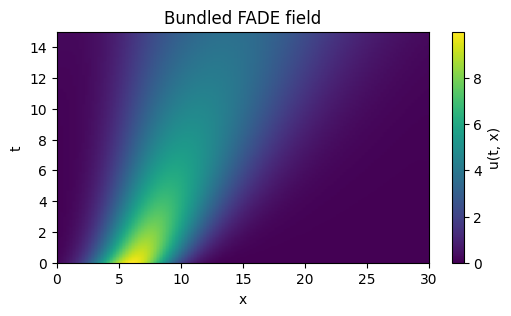

In [3]:
fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(
    data.U,
    origin="lower",
    aspect="auto",
    extent=[data.x[0], data.x[-1] + data.dx, data.t[0], data.t[-1] + data.dt],
)
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title("Bundled FADE field")
fig.colorbar(im, ax=ax, label="u(t, x)")
plt.show()

## 2. Construct the weak-form library

Each regression row is an integral measurement against a separable smooth test
function. For linear terms, the fractional operator is transferred to the test
function through the discrete adjoint.

In [4]:
bank = build_weak_candidate_library(
    data,
    config,
    test_budget="smoke",
    verbose=True,
)
print("Weak rows:", bank.n_points)
print("Time tests:", bank.time_tests.shape)
print("Space tests:", bank.space_tests.shape)
print("Temporal modes:", bank.available_alpha_modes())

[paper_FADE_tsfade_fft] precomputing weak features: 47 alpha orders, 59 beta orders, 336 weak rows


[paper_FADE_tsfade_fft] weak feature bank ready in 0.30s
Weak rows: 336
Time tests: (14, 150)
Space tests: (24, 120)
Temporal modes: ('fractional_subunit', 'integer', 'fractional_superunit')


## 3. Inspect one candidate equation by hand

In [5]:
target = bank.target(0.80, alpha_mode="fractional_subunit")
theta = bank.library((0, 0), (1.0, 1.7))
coef, diagnostics = fit_least_squares(theta, target, ridge=config.ridge)
print("Target shape:", target.shape)
print("Library shape:", theta.shape)
print("Estimated coefficients:", coef)
print("Relative residual:", diagnostics["rel_rmse"])

Target shape: (336,)
Library shape: (336, 2)
Estimated coefficients: [-1.00575036  0.49609605]
Relative residual: 0.0020552596078953368


## 4. Run Pareto-based best-subset selection

The optimizer finds the best candidate at each support size. The final model is
selected from the validation-error--complexity front.

In [6]:
problem = build_best_subset_pareto_problem(bank, config)
summary = run_best_subset_pareto_de(
    problem,
    config,
    data=data,
    output_dir=OUTPUT_DIR,
    verbose=False,
)
print("Selected equation:")
print(summary["selected"]["equation"])

Selected equation:
D_t^0.79950 u = (-1.0068)*D_x^1.00000 u + (0.49614)*D_x^1.70000 u


In [7]:
progress = pd.DataFrame(summary["support_size_progress"])
progress[["c", "val_rel_mse", "equation"]]

,c,val_rel_mse,equation
0,1,0.010015,D_t^0.836112 u = (-0.716577)*D_x^0.872122 u
1,2,0.000004,D_t^0.799500 u = (-1.00679)*D_x^1.000000 u + (...


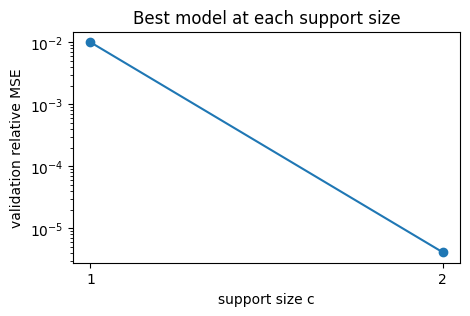

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(progress["c"], progress["val_rel_mse"], marker="o")
ax.set_yscale("log")
ax.set_xlabel("support size c")
ax.set_ylabel("validation relative MSE")
ax.set_title("Best model at each support size")
ax.set_xticks(progress["c"])
plt.show()

## 5. Move from tutorial to paper settings

The tutorial restricts the right-hand-side powers to `p_values=(0,)`, uses
`cmax=2`, and uses a small differential-evolution budget. The manuscript uses
an overcomplete power set, larger support cap, full budgets, and five seeds.
See `docs/PAPER_RESULTS_GUIDE.md` and `reproduce/README.md` for the exact commands.